---
title: "Homework 2 Answers Kaggle Competition: Predicting Irrigation Need"
author: Karisa Kopecek
date: today
format:
  html:
    embed-resources: true
    echo: true
---

### Disclaimer: I ended up having to delete some of my hyperparameter trials just for clarity. I only included the top 3 manual hyperparameter results and then used those results to inform the optuna result which in both cases ended up being the best scorer. I still talk about some of what I found with those earlier trials of hyperparameters below though. So it may look like I didn't follow "That is, try not to run three different sets of hyperparameters that result in the same performance.": but I did try other very different hyperparameters with very different results, just narrowed down to the top 3 which ended up looking similar.

## Boosting Model 1:

Link: https://github.com/karisamarykopecek/Kaggle_Comp_Irrigation/blob/main/BoostingModel1.ipynb

## Boosting Model 2:

Link: https://github.com/karisamarykopecek/Kaggle_Comp_Irrigation/blob/main/BoostingModel2.ipynb

## Discuss your modeling approaches. What did you try? 

I did one notebook with XGBoost and one with LightGBM. My method for both notebooks invovled first testing manual hyperparameters. I tried a lot of different variations of numbers (not all shown for simplicity's sake). Eventually I got to a point where I felt like I had "maxed out" the manual preformance of the hyperparameters. At that point I kept those top 3 hyperparameters (you can see them in both notebooks) and then I used what I learned to run Optuna. I started with 30 trials, which as discussed in class didn't work as well, so then I switched to 50 (you can see this version in my final notebooks). For XGBoost the 3 main hyperparameters tested regularization with min_child_weight, leaf-wise tree growth using grow_policy='lossguide', and deeper trees with aggressive subsampling. For LightGBM the hyperparameters tested a low-complexity few-leaves setup, deeper trees with aggressive subsampling, and explicit L1/L2 regularization on top of that. I fed whatever I felt like was working well into Optuna. Both models used the same engineered features from earlier notebooks and a 30K stratified CV sample. 

## What worked well? 

For XGBoost, the best manual config was Config B (leaf-wise growth) at 0.9822. That result informed the Optuna search, which was set up to test both depthwise and leaf-wise tree building. Optuna confirmed leaf-wise was the better approach by selecting it in both tuning runs, and the final Optuna-tuned XGBoost scored 0.96419 on the leaderboard. For LightGBM, Config B (deeper trees with aggressive subsampling) was the best manual config at 0.9815. Optuna searched a similar range and the final submission scored 0.96380. Optuna worked better than doing everything manually, especially once I had better ranges to test from my manual experiments. XGBoost overall continues to be the model preforming the best for me. 


## What didn't work well? 

For XGBoost, earlier configs that used shallower trees (max_depth=3), very high learning rates (0.3), or no subsampling performed noticeably worse and were dropped before the final three. Even among the final three manual configs, heavier regularization in Config A did not improve over simpler approaches, and all three landed within 0.0002 of each other between 0.9820 and 0.9822. Optuna also struggled to beat the best manual score sometimes especially before increasing to 50. For LightGBM, the original Config B used 200 leaves with min_child_samples=5, which performed the worst of any config at 0.9808, likely because too many leaves with almost no minimum sample requirement caused overfitting. Adding explicit L1 and L2 regularization in the final Config C also made things slightly worse at 0.9810, suggesting the subsampling and class weighting already built into LightGBM were doing enough on their own.

## Were model improvements meaningful or small? 

Model improvements were small, but even a small difference in performance is kind of a lot (the leaderboard on Kaggle has positions separated only by a small amount at the top). All manual XGBoost configs landed within 0.0002 of each other and all LightGBM configs within 0.0005. The dataset is clean and sometimes the models find the same patterns even with a lot of tuning. The bigger gap was between using the two different models. Even Optuna even though i tried varying it a lot couldn't find a ton better preformance compared to what I got manually.

## Table:

| Model | Family | CV Weighted F1 | Leaderboard |
|---|---|---|---|
| XGBoost Config A (Deep + Reg + min_child) | Boosting | 0.9821 (sd 0.0004) | - |
| XGBoost Config B (Leaf-wise Growth) | Boosting | 0.9822 (sd 0.0005) | - |
| XGBoost Config C (Deeper + Aggressive Subsample) | Boosting | 0.9820 (sd 0.0005) | - |
| XGBoost Config D (Optuna) | Boosting | 0.9822 (sd 0.0008) | 0.96419 |
| LightGBM Config A (Few Leaves/High LR) | Boosting | 0.9814 (sd 0.0006) | - |
| LightGBM Config B (Deeper + Aggressive Subsample) | Boosting | 0.9815 (sd 0.0005) | - |
| LightGBM Config C (Explicit Regularization) | Boosting | 0.9810 (sd 0.0003) | - |
| LightGBM Config D (Optuna) | Boosting | - | 0.96380 |

## Overall Leaderboard Position:
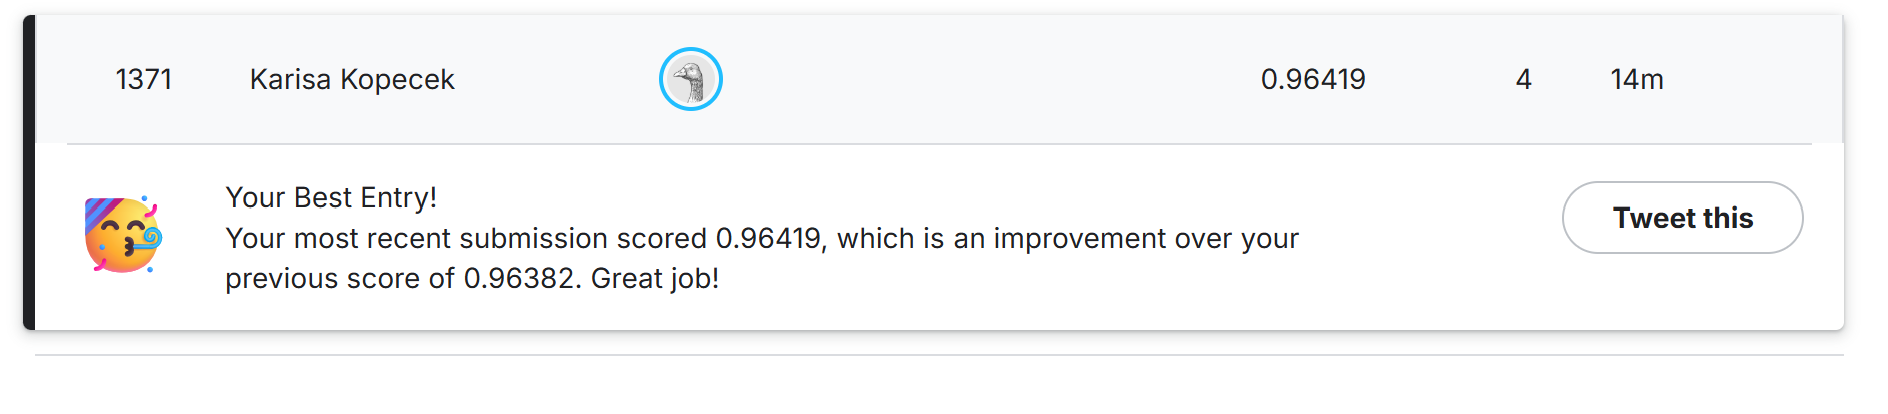

## How did the different models compare for your work? 

XGBoost outperformed LightGBM by about 0.0007 in CV and 0.00039 on the leaderboard (0.96419 vs 0.96380). Both beat the previous best submission. See the above table for other numerical results. 